# Import Required Libraries

The required Python libraries for image processing, deep learning, model evaluation, visualization and Grad-CAM explainability.

In [109]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

from tqdm import tqdm

import torch.nn.functional as F

# Set Random Seed

A fixed random seed was set to ensure reproducibility of the experimental results. This ensures consistent dataset splitting, model initialization, and training behavior across different runs.

In [140]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Dataset Loading and Preprocessing

The brain MRI dataset was loaded using PyTorch's `ImageFolder` class. Separate directories were used for the training and testing datasets.

All images were resized to **224 × 224** pixels and converted into tensors, making them compatible with the pretrained CNN models.

In [4]:
# Dataset paths
train_dir = "./data/Training"
test_dir = "./data/Testing"

# Training Transform (Baseline)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Testing Transform (Baseline)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Load datasets
train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=test_transform
)

In [5]:
# Display dataset information
print(f"Training Images : {len(train_dataset)}")
print(f"Testing Images  : {len(test_dataset)}")

print("\nClasses:")
print(train_dataset.classes)

print("\nClass to Index Mapping:")
print(train_dataset.class_to_idx)

Training Images : 5600
Testing Images  : 1600

Classes:
['glioma', 'meningioma', 'notumor', 'pituitary']

Class to Index Mapping:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


# Dataset Visualization

A sample MRI image from each tumor category was displayed to visually inspect the dataset. This provides an overview of the different classes and helps verify that the images have been loaded correctly before model training.

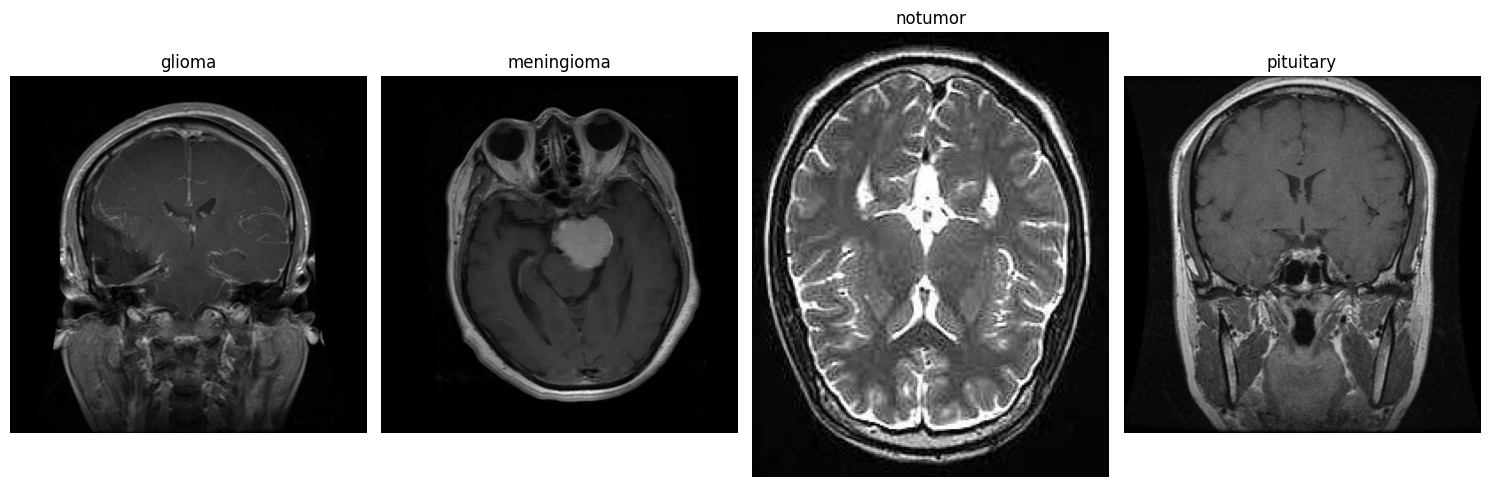

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(15,5))

for i, class_name in enumerate(train_dataset.classes):

    class_path = os.path.join(train_dir, class_name)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    axes[i].imshow(image, cmap="gray")
    axes[i].set_title(class_name)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [7]:
image, label = train_dataset[0]

print(type(image))
print(type(label))

print("Image Shape :", image.shape)
print("Label :", label)

<class 'torch.Tensor'>
<class 'int'>
Image Shape : torch.Size([3, 224, 224])
Label : 0


# Verify Image Format

The color mode of a sample MRI image was checked to verify the input image format before training. This ensures that the dataset is loaded correctly and is compatible with the preprocessing pipeline used by the pretrained CNN models.

In [8]:
from PIL import Image

img = Image.open(train_dataset.samples[0][0])
print(img.mode)

L


# Create Data Loaders

PyTorch `DataLoader` objects were created for both the training and testing datasets. A batch size of **32** was used for efficient training, with shuffling enabled for the training data to improve model generalization and disabled for the testing data to ensure consistent evaluation.

In [9]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

# Verify Batch Dimensions

A sample batch was retrieved from the training data loader to verify the input pipeline. The shapes of the image and label tensors were inspected to confirm that the data was correctly batched before training.

- **Images:** `(batch_size, channels, height, width)`
- **Labels:** `(batch_size)`

In [11]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


# Visualize Training Batch

A sample batch of MRI images along with their corresponding class labels was visualized to verify that the data loader is functioning correctly. This step helps ensure that the images and labels are properly aligned before model training begins.

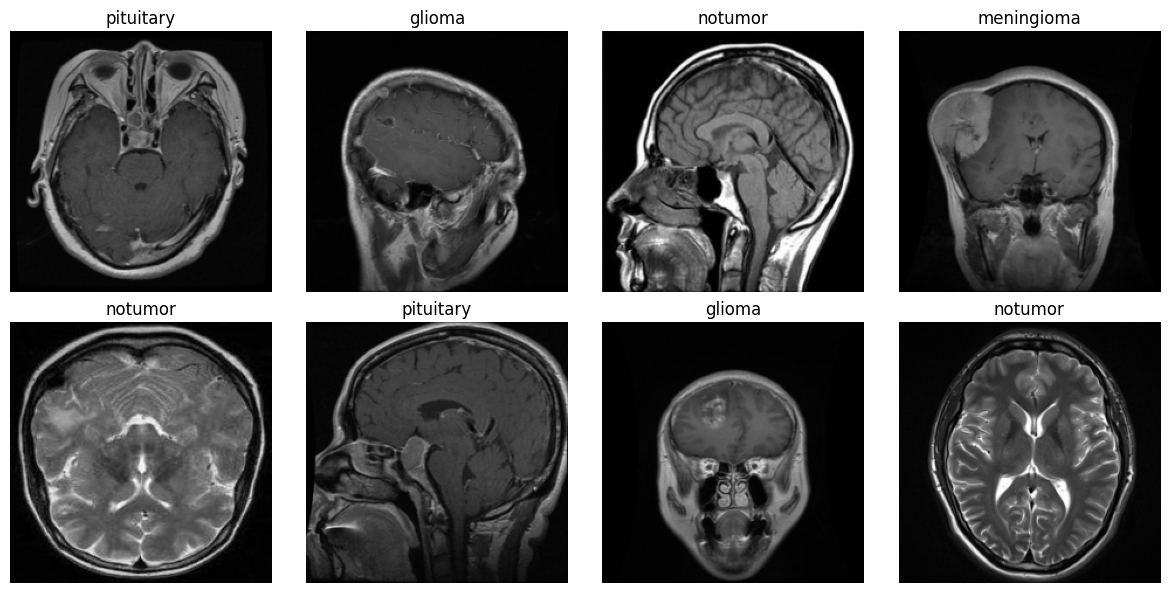

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    image = images[i].permute(1, 2, 0)
    label = labels[i]

    ax.imshow(image)
    ax.set_title(train_dataset.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

# Configure Computing Device

The computation device was automatically detected to utilize available hardware resources. If a CUDA-enabled GPU is available, the model training and inference are performed on the GPU to accelerate computation; otherwise, the CPU is used.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# Load Pretrained ResNet50

A pretrained **ResNet50** model was loaded using weights trained on the **ImageNet** dataset. Transfer learning enables the model to leverage previously learned visual features, reducing training time and improving performance on the brain tumor classification task.

The architecture was inspected to identify the final fully connected classification layer, which was later replaced to match the four target classes in the dataset.

In [14]:
from torchvision import models

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

print(model.fc)

Linear(in_features=2048, out_features=1000, bias=True)


# Load Pretrained DenseNet121

A pretrained **DenseNet121** model was loaded using weights trained on the **ImageNet** dataset. DenseNet121 utilizes dense connectivity between layers, promoting feature reuse and efficient gradient flow while reducing the number of trainable parameters.

The final classification layer was inspected before being replaced with a custom classifier for the four brain tumor classes.

In [20]:
model2 = models.densenet121(
    weights=models.DenseNet121_Weights.DEFAULT
)

# Load Pretrained EfficientNet-B0

A pretrained **EfficientNet-B0** model was loaded using weights trained on the **ImageNet** dataset. EfficientNet-B0 employs a compound scaling strategy that balances network depth, width, and input resolution to achieve high accuracy with relatively fewer parameters.

The final classification layer was examined before being modified to perform four-class brain tumor classification.

In [21]:
model3 = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

# Modify the Classification Layer

The original ResNet50 model was pretrained on the ImageNet dataset for **1,000 image classes**. Since this project involves classifying MRI images into **four brain tumor categories**, the final fully connected classification layer was replaced with a new layer containing four output neurons.

This allows the pretrained feature extractor to be adapted to the brain tumor classification task through transfer learning.

In [22]:
num_classes = len(train_dataset.classes)

model.fc = nn.Linear(
    in_features=model.fc.in_features,
    out_features=num_classes
)

# Configure Models for Transfer Learning

To apply transfer learning, the pretrained feature extraction layers of each CNN model (**ResNet50**, **DenseNet121**, and **EfficientNet-B0**) were frozen, preventing their weights from being updated during training.

Only the final classification layer was left trainable and replaced with a custom classifier for the four brain tumor classes. This approach preserves the rich visual features learned from the ImageNet dataset while allowing the models to adapt efficiently to the brain MRI classification task.

Finally, each model was moved to the selected computation device (CPU or GPU) for training and inference.

In [68]:
# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze Final Classifier
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

In [69]:
model2.classifier = nn.Linear(
    model2.classifier.in_features,
    num_classes
)

for param in model2.parameters():
    param.requires_grad = False

for param in model2.classifier.parameters():
    param.requires_grad = True

model2 = model2.to(device)

In [70]:
model3.classifier[1] = nn.Linear(
    model3.classifier[1].in_features,
    num_classes
)

for param in model3.parameters():
    param.requires_grad = False

for param in model3.classifier.parameters():
    param.requires_grad = True

model3 = model3.to(device)

In [71]:
print(model.fc)

Linear(in_features=2048, out_features=4, bias=True)


In [72]:
print(model2.classifier)

Linear(in_features=1024, out_features=4, bias=True)


In [73]:
print(model3.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)


# Model Summary

The total and trainable parameters of each model were calculated to understand their computational complexity and the effect of transfer learning. Since only the final classification layer was unfrozen, the majority of the pretrained parameters remained frozen, significantly reducing the number of trainable parameters while preserving the knowledge learned from the ImageNet dataset.

Comparing these values also provides insight into the relative size and efficiency of ResNet50, DenseNet121, and EfficientNet-B0.

In [74]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 23,516,228
Trainable Parameters : 8,196


In [75]:
total_params2 = sum(p.numel() for p in model2.parameters())
trainable_params2 = sum(p.numel() for p in model2.parameters() if p.requires_grad)

print(f"Total Parameters     : {total_params2:,}")
print(f"Trainable Parameters : {trainable_params2:,}")

Total Parameters     : 6,957,956
Trainable Parameters : 4,100


In [76]:
total_params3 = sum(p.numel() for p in model3.parameters())
trainable_params3 = sum(p.numel() for p in model3.parameters() if p.requires_grad)

print(f"Total Parameters     : {total_params3:,}")
print(f"Trainable Parameters : {trainable_params3:,}")

Total Parameters     : 4,012,672
Trainable Parameters : 5,124


# Define Loss Function, Optimizer, and Learning Rate Scheduler

The training configuration was initialized by defining the loss function, optimizer, and learning rate scheduler.

- **Cross-Entropy Loss** was used as the objective function for the multi-class brain tumor classification task.
- The **Adam optimizer** was selected to efficiently update the trainable parameters by adapting the learning rate during optimization.
- A **ReduceLROnPlateau** learning rate scheduler was employed to automatically reduce the learning rate whenever the validation loss stopped improving for a specified number of epochs. This helps the model converge more effectively, minimizes training stagnation, and can improve overall generalization performance.

In [158]:
import torch.nn as nn
import torch.optim as optim

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2
)

In [191]:
criterion2 = nn.CrossEntropyLoss()

optimizer2 = optim.Adam(
    model2.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer2, 
    mode="min",
    factor=0.1,
    patience=2  
)

In [213]:
criterion3 = nn.CrossEntropyLoss()

optimizer3 = optim.Adam(
    model3.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler3 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer3, 
    mode="min",
    factor=0.1,
    patience=2  
)

# Training Configuration

The training process was configured to run for **15 epochs**. Initially, the models were trained for **10 epochs**; however, the number of epochs was increased to **15** to allow the models to learn more effectively and achieve improved validation performance.

Lists were initialized to store the training and validation loss and accuracy after each epoch, enabling the visualization of learning curves. Additionally, the best validation accuracy was tracked so that the best-performing model could be saved during training.

In [25]:
num_epochs = 15

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_accuracy = 0.0

In [26]:
num_epochs2 = 15

train_losses2 = []
train_accuracies2 = []

val_losses2 = []
val_accuracies2 = []

best_val_accuracy2 = 0.0

In [27]:
num_epochs3 = 15

train_losses3 = []
train_accuracies3 = []

val_losses3 = []
val_accuracies3 = []

best_val_accuracy3 = 0.0

# Model Training and Validation

The model was trained for **15 epochs** using the training dataset. During each epoch, a forward pass was performed to generate predictions, followed by the computation of the Cross-Entropy loss. The loss was then backpropagated to update the trainable parameters using the Adam optimizer.

After completing each training epoch, the model was evaluated on the validation (test) dataset without updating the model weights. Training and validation loss and accuracy were recorded to monitor the learning progress and detect potential overfitting.

The model achieving the highest validation accuracy was automatically saved for later evaluation. Additionally, the learning rate scheduler monitored the validation loss and reduced the learning rate whenever the model's performance plateaued, helping improve convergence during training.

In [160]:
for epoch in range(num_epochs):

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # Training

    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total = 0

    for images, labels in train_loader:

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Accumulate loss
        running_loss += loss.item() * images.size(0)

        # Predictions
        _, predicted = torch.max(outputs, dim=1)

        total += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    # Training metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_accuracy = 100 * correct_predictions / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f"Training Loss     : {epoch_loss:.4f}")
    print(f"Training Accuracy : {epoch_accuracy:.4f}%")

    # Validation

    model.eval()

    val_running_loss = 0.0
    val_correct_predictions = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            # Move data to GPU
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Accumulate loss
            val_running_loss += loss.item() * images.size(0)

            # Predictions
            _, predicted = torch.max(outputs, dim=1)

            val_total += labels.size(0)
            val_correct_predictions += (predicted == labels).sum().item()

    # Validation metrics
    val_loss = val_running_loss / len(test_loader.dataset)
    val_accuracy = 100 * val_correct_predictions / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Validation Loss     : {val_loss:.4f}")
    print(f"Validation Accuracy : {val_accuracy:.4f}%")

    # Save best model
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), "resnet50_model.pth")
        print("✅ Best model saved!")

    # Update scheduler
    scheduler.step(val_loss)


Epoch 1/15


Training Loss     : 0.6445
Training Accuracy : 81.2321%
Validation Loss     : 0.8382
Validation Accuracy : 78.8750%
✅ Best model saved!

Epoch 2/15
Training Loss     : 0.3944
Training Accuracy : 87.8214%
Validation Loss     : 0.6988
Validation Accuracy : 81.0625%
✅ Best model saved!

Epoch 3/15
Training Loss     : 0.3293
Training Accuracy : 89.3214%
Validation Loss     : 1.0161
Validation Accuracy : 83.4375%
✅ Best model saved!

Epoch 4/15
Training Loss     : 0.2965
Training Accuracy : 90.5893%
Validation Loss     : 0.7623
Validation Accuracy : 82.8750%

Epoch 5/15
Training Loss     : 0.2711
Training Accuracy : 91.0000%
Validation Loss     : 0.5056
Validation Accuracy : 85.0625%
✅ Best model saved!

Epoch 6/15
Training Loss     : 0.2447
Training Accuracy : 92.0893%
Validation Loss     : 1.5605
Validation Accuracy : 83.8125%

Epoch 7/15
Training Loss     : 0.2323
Training Accuracy : 92.3214%
Validation Loss     : 0.5981
Validation Accuracy : 84.1875%

Epoch 8/15
Training Loss     : 0.22

In [193]:
for epoch in range(num_epochs):

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # Training
    model2.train()

    running_loss = 0.0
    correct_predictions = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer2.zero_grad()

        outputs = model2(images)

        loss = criterion2(outputs, labels)

        loss.backward()

        optimizer2.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, dim=1)

        total += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_accuracy = 100 * correct_predictions / total

    train_losses2.append(epoch_loss)
    train_accuracies2.append(epoch_accuracy)

    print(f"Training Loss     : {epoch_loss:.4f}")
    print(f"Training Accuracy : {epoch_accuracy:.4f}%")

    # Validation
    model2.eval()

    val_running_loss = 0.0
    val_correct_predictions = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model2(images)

            loss = criterion2(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, dim=1)

            val_total += labels.size(0)
            val_correct_predictions += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(test_loader.dataset)
    val_accuracy = 100 * val_correct_predictions / val_total

    val_losses2.append(val_loss)
    val_accuracies2.append(val_accuracy)

    print(f"Validation Loss     : {val_loss:.4f}")
    print(f"Validation Accuracy : {val_accuracy:.4f}%")

    if val_accuracy > best_val_accuracy2:
        best_val_accuracy2 = val_accuracy
        torch.save(model2.state_dict(), "densenet121_model.pth")
        print("✅ Best model saved!")

    scheduler2.step(val_loss)


Epoch 1/15
Training Loss     : 0.6602
Training Accuracy : 77.1964%
Validation Loss     : 0.5431
Validation Accuracy : 80.0625%
✅ Best model saved!

Epoch 2/15
Training Loss     : 0.3922
Training Accuracy : 86.5893%
Validation Loss     : 0.4911
Validation Accuracy : 81.8750%
✅ Best model saved!

Epoch 3/15
Training Loss     : 0.3353
Training Accuracy : 88.2321%
Validation Loss     : 0.4547
Validation Accuracy : 84.3125%
✅ Best model saved!

Epoch 4/15
Training Loss     : 0.3006
Training Accuracy : 89.6429%
Validation Loss     : 0.4560
Validation Accuracy : 84.3750%
✅ Best model saved!

Epoch 5/15
Training Loss     : 0.2787
Training Accuracy : 89.9821%
Validation Loss     : 0.4724
Validation Accuracy : 84.4375%
✅ Best model saved!

Epoch 6/15
Training Loss     : 0.2659
Training Accuracy : 90.7321%
Validation Loss     : 0.4621
Validation Accuracy : 85.5000%
✅ Best model saved!

Epoch 7/15
Training Loss     : 0.2394
Training Accuracy : 91.5179%
Validation Loss     : 0.4427
Validation Accu

In [ ]:
for epoch in range(num_epochs):

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # Training
    model3.train()

    running_loss = 0.0
    correct_predictions = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer3.zero_grad()

        outputs = model3(images)

        loss = criterion3(outputs, labels)

        loss.backward()

        optimizer3.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, dim=1)

        total += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_accuracy = 100 * correct_predictions / total

    train_losses3.append(epoch_loss)
    train_accuracies3.append(epoch_accuracy)

    print(f"Training Loss     : {epoch_loss:.4f}")
    print(f"Training Accuracy : {epoch_accuracy:.4f}%")

    # Validation
    model3.eval()

    val_running_loss = 0.0
    val_correct_predictions = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model3(images)

            loss = criterion3(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, dim=1)

            val_total += labels.size(0)
            val_correct_predictions += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(test_loader.dataset)
    val_accuracy = 100 * val_correct_predictions / val_total

    val_losses3.append(val_loss)
    val_accuracies3.append(val_accuracy)-

    print(f"Validation Loss     : {val_loss:.4f}")
    print(f"Validation Accuracy : {val_accuracy:.4f}%")

    if val_accuracy > best_val_accuracy3:
        best_val_accuracy3 = val_accuracy
        torch.save(model3.state_dict(), "efficientnet_b0_model.pth")
        print("✅ Best model saved!")

    scheduler3.step(val_loss)


Epoch 1/15
Training Loss     : 0.5989
Training Accuracy : 80.7321%
Validation Loss     : 0.5179
Validation Accuracy : 81.3750%
✅ Best model saved!

Epoch 2/15
Training Loss     : 0.3818
Training Accuracy : 87.3929%
Validation Loss     : 0.4774
Validation Accuracy : 83.3750%
✅ Best model saved!

Epoch 3/15
Training Loss     : 0.3451
Training Accuracy : 88.0536%
Validation Loss     : 0.4358
Validation Accuracy : 85.5000%
✅ Best model saved!

Epoch 4/15
Training Loss     : 0.3215
Training Accuracy : 88.9286%
Validation Loss     : 0.4490
Validation Accuracy : 84.7500%

Epoch 5/15
Training Loss     : 0.2901
Training Accuracy : 89.8393%
Validation Loss     : 0.4234
Validation Accuracy : 86.3125%
✅ Best model saved!

Epoch 6/15
Training Loss     : 0.2961
Training Accuracy : 90.0000%
Validation Loss     : 0.4190
Validation Accuracy : 86.7500%
✅ Best model saved!

Epoch 7/15
Training Loss     : 0.2786
Training Accuracy : 90.2321%
Validation Loss     : 0.4153
Validation Accuracy : 87.0000%
✅ Be

# Load the Best Trained Model

After training, the model with the highest validation accuracy was loaded from the saved checkpoint. Using the best-performing model ensures that all subsequent evaluations, predictions, external image testing, and Grad-CAM visualizations are performed using the most accurate version of the trained network.

In [ ]:
# Load ResNet Model

model.load_state_dict(torch.load("resnet50_model.pth"))
model.eval()

In [ ]:
# Load DenseNet Model

model2.load_state_dict(torch.load("densenet121_model.pth"))
model2.eval()

In [ ]:
model3.load_state_dict(torch.load("efficientnet_b0_model.pth"))
model3.eval()

# Generate Predictions and Evaluate Test Accuracy

The best-trained model was used to perform inference on the test dataset. During evaluation, gradient computation was disabled to improve computational efficiency and reduce memory usage, as no parameter updates were required.

The true class labels and the corresponding predicted labels were collected for all test images. These predictions were then used to compute the **overall test accuracy**, providing a quantitative measure of the model's classification performance on unseen data. The collected labels were also used in subsequent analyses, including the **classification report** and **confusion matrix**.

In [80]:
all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

In [81]:
accuracy = accuracy_score(all_labels, all_predictions)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 86.81%


In [82]:
all_labels2 = []
all_predictions2 = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model2(images)

        _, predicted = torch.max(outputs, dim=1)

        all_labels2.extend(labels.cpu().numpy())
        all_predictions2.extend(predicted.cpu().numpy())

In [83]:
accuracy2 = accuracy_score(all_labels2, all_predictions2)

print(f"Test Accuracy: {accuracy2 * 100:.2f}%")

Test Accuracy: 86.75%


In [84]:
all_labels3 = []
all_predictions3 = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model3(images)

        _, predicted = torch.max(outputs, dim=1)

        all_labels3.extend(labels.cpu().numpy())
        all_predictions3.extend(predicted.cpu().numpy())

In [85]:
accuracy3 = accuracy_score(all_labels3, all_predictions3)

print(f"Test Accuracy: {accuracy3 * 100:.2f}%") 

Test Accuracy: 87.75%


# Classification Report

A detailed **classification report** was generated to evaluate the performance of the model on each brain tumor class individually. The report includes **precision**, **recall**, **F1-score**, and **support** for every class, providing a comprehensive assessment of the model's classification capabilities beyond overall accuracy.

These metrics help identify class-specific strengths and weaknesses, making them particularly useful for evaluating performance on imbalanced datasets and understanding the model's ability to correctly classify each tumor category.

In [86]:
print(classification_report(
    all_labels,
    all_predictions,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

      glioma       0.95      0.67      0.79       400
  meningioma       0.76      0.89      0.82       400
     notumor       0.86      0.98      0.91       400
   pituitary       0.95      0.94      0.94       400

    accuracy                           0.87      1600
   macro avg       0.88      0.87      0.87      1600
weighted avg       0.88      0.87      0.87      1600



In [87]:
print(classification_report(
    all_labels2,    
    all_predictions2,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

      glioma       0.94      0.71      0.81       400
  meningioma       0.78      0.82      0.80       400
     notumor       0.86      0.99      0.92       400
   pituitary       0.91      0.95      0.93       400

    accuracy                           0.87      1600
   macro avg       0.87      0.87      0.86      1600
weighted avg       0.87      0.87      0.86      1600



In [88]:
print(classification_report(
    all_labels3,
    all_predictions3,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

      glioma       0.96      0.71      0.81       400
  meningioma       0.81      0.85      0.83       400
     notumor       0.86      0.99      0.92       400
   pituitary       0.92      0.96      0.94       400

    accuracy                           0.88      1600
   macro avg       0.88      0.88      0.87      1600
weighted avg       0.88      0.88      0.87      1600



# Confusion Matrix

A **confusion matrix** was generated to visualize the classification performance of the model across all brain tumor classes. It compares the true class labels with the predicted labels, allowing correct and incorrect predictions to be examined for each category.

The heatmap representation provides a clear overview of the model's strengths and highlights any misclassifications between different tumor types, making it an effective tool for evaluating classification performance.

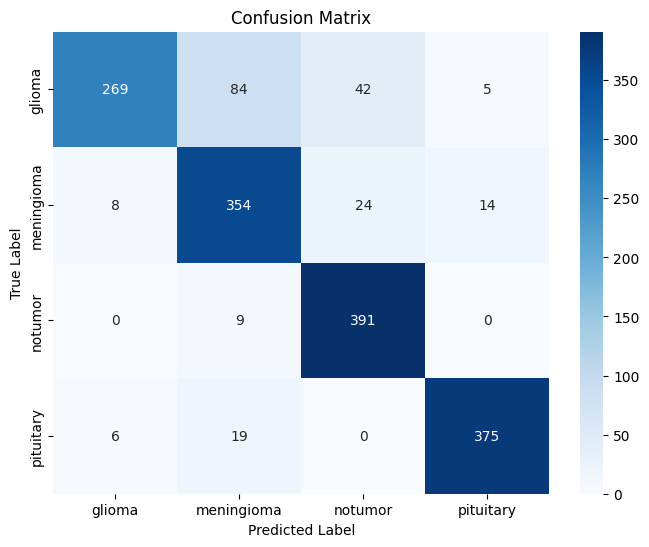

In [89]:
import seaborn as sns

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

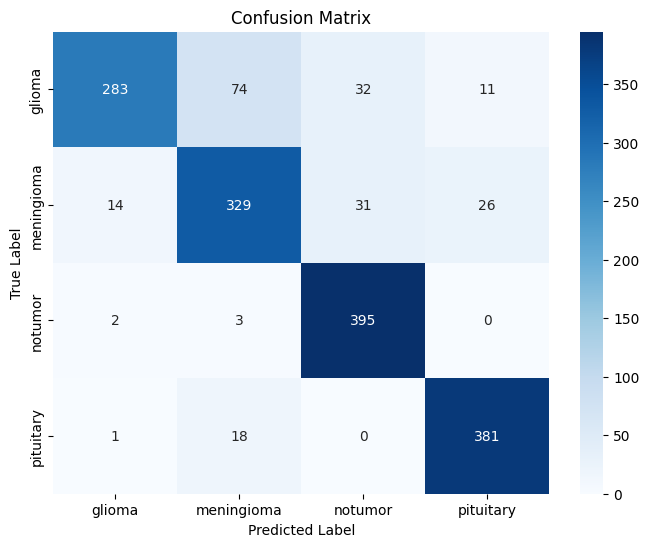

In [90]:
cm2 = confusion_matrix(all_labels2, all_predictions2)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm2,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

<Axes: >

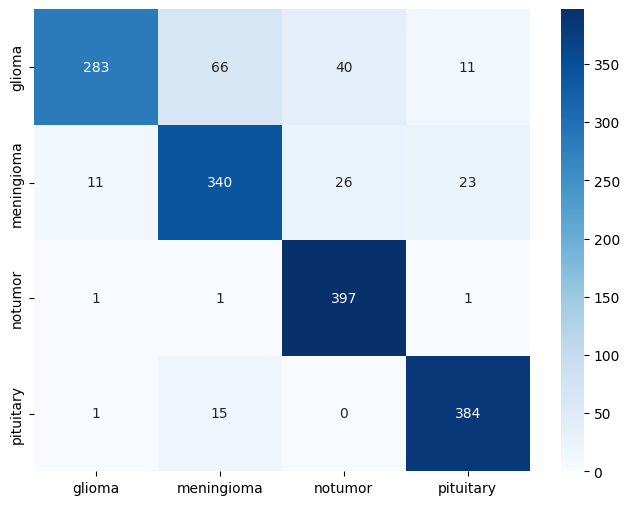

In [91]:
cm3 = confusion_matrix(all_labels3, all_predictions3)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm3,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

# Explainable AI using Grad-CAM

To improve the interpretability of the trained model, **Gradient-weighted Class Activation Mapping (Grad-CAM)** was employed. Grad-CAM generates a heatmap that highlights the regions of an MRI image that contributed most to the model's prediction, providing insight into the model's decision-making process.

For each input image, the model predicts the brain tumor class and its corresponding confidence score. A Grad-CAM heatmap is then generated using the final convolutional layer and overlaid on the original MRI image, allowing the areas of greatest importance to be visualized. This enhances the transparency and reliability of the model by demonstrating that predictions are based on clinically relevant image regions rather than irrelevant features.

In [140]:
# Class names
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

def predict_with_gradcam_resnet(image_path, model, device):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image_resized = image.resize((224, 224))

    rgb_img = np.array(image_resized).astype(np.float32) / 255.0

    input_tensor = test_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = F.softmax(outputs, dim=1)[0]

    confidence, predicted = torch.max(probabilities, dim=0)

    predicted_class = class_names[predicted.item()]
    confidence = confidence.item() * 100

    target_layers = [model.layer4[-1]]

    with GradCAM(model=model, target_layers=target_layers) as cam:
        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=[ClassifierOutputTarget(predicted.item())]
        )[0]

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    fig, ax = plt.subplots(1,2, figsize=(12,6))

    ax[0].imshow(image_resized)
    ax[0].set_title("Original MRI")
    ax[0].axis("off")

    ax[1].imshow(visualization)
    ax[1].set_title(f"Grad-CAM\n{predicted_class} ({confidence:.2f}%)")
    ax[1].axis("off")

    plt.show()

    return predicted_class, confidence

In [143]:
def predict_with_gradcam_densenet(image_path, model2, device):
    model2.eval()

    image = Image.open(image_path).convert("RGB")
    image_resized = image.resize((224,224))

    rgb_img = np.array(image_resized).astype(np.float32)/255.0

    input_tensor = test_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model2(input_tensor)
        probabilities = F.softmax(outputs, dim=1)[0]

    confidence, predicted = torch.max(probabilities, dim=0)

    predicted_class = class_names[predicted.item()]
    confidence = confidence.item()*100

    target_layers = [model2.features[-1]]

    with GradCAM(model=model2, target_layers=target_layers) as cam:
        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=[ClassifierOutputTarget(predicted.item())]
        )[0]

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    fig, ax = plt.subplots(1,2, figsize=(12,6))

    ax[0].imshow(image_resized)
    ax[0].set_title("Original MRI")
    ax[0].axis("off")

    ax[1].imshow(visualization)
    ax[1].set_title(f"Grad-CAM\n{predicted_class} ({confidence:.2f}%)")
    ax[1].axis("off")

    plt.show()

    return predicted_class, confidence

In [145]:
def predict_with_gradcam_efficientnet(image_path, model3, device):
    model3.eval()

    image = Image.open(image_path).convert("RGB")
    image_resized = image.resize((224,224))

    rgb_img = np.array(image_resized).astype(np.float32)/255.0

    input_tensor = test_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model3(input_tensor)
        probabilities = F.softmax(outputs, dim=1)[0]

    confidence, predicted = torch.max(probabilities, dim=0)

    predicted_class = class_names[predicted.item()]
    confidence = confidence.item()*100

    target_layers = [model3.features[-1]]

    with GradCAM(model=model3, target_layers=target_layers) as cam:
        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=[ClassifierOutputTarget(predicted.item())]
        )[0]

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    fig, ax = plt.subplots(1,2, figsize=(12,6))

    ax[0].imshow(image_resized)
    ax[0].set_title("Original MRI")
    ax[0].axis("off")

    ax[1].imshow(visualization)
    ax[1].set_title(f"Grad-CAM\n{predicted_class} ({confidence:.2f}%)")
    ax[1].axis("off")

    plt.show()

    return predicted_class, confidence

In [141]:
for param in model.parameters():
    param.requires_grad = True

# model.eval()

In [ ]:
for param in model2.parameters():
    param.requires_grad = True
    

In [146]:
for param in model3.parameters():
    param.requires_grad = True

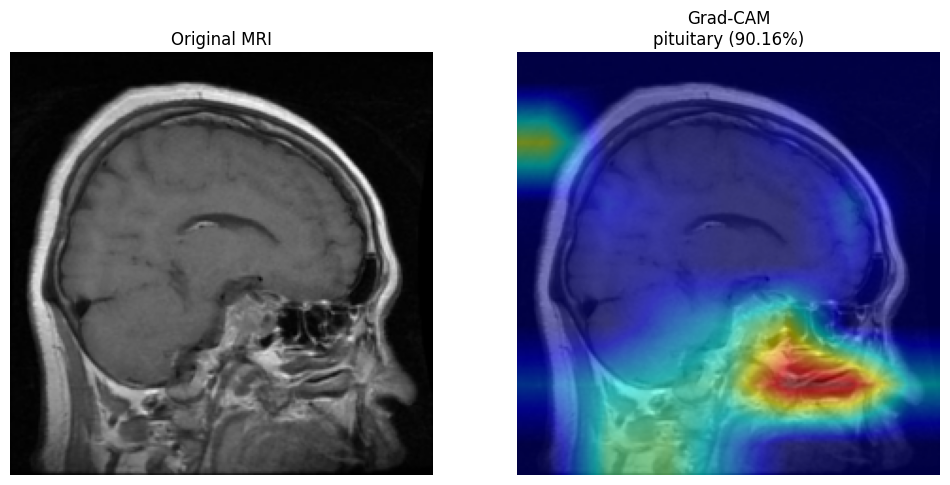

('pituitary', 90.1604950428009)

In [209]:
predict_with_gradcam_resnet(
    "data\\Testing\\pituitary\\Te-pi_36.jpg",
    model,
    device
)

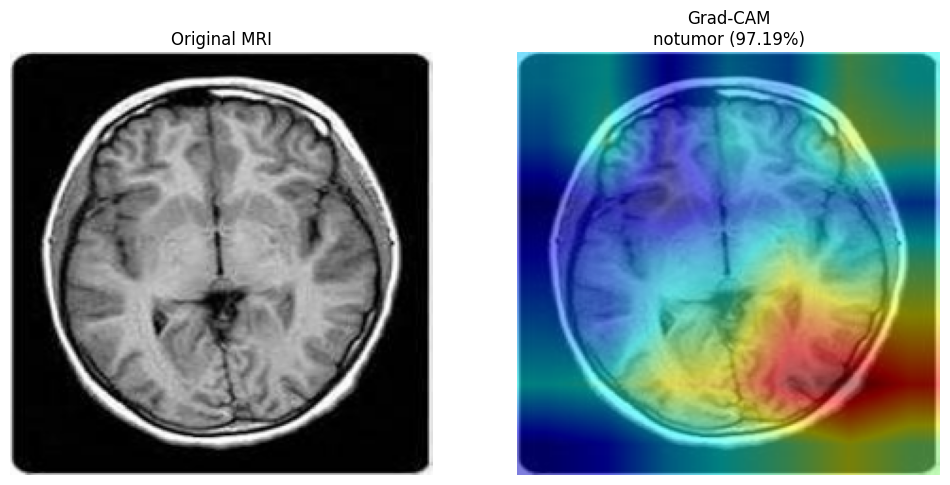

('notumor', 97.19056487083435)

In [ ]:
predict_with_gradcam_densenet(
    "data\\Testing\\pituitary\\Te-pi_36.jpg",
    model2,
    device
)

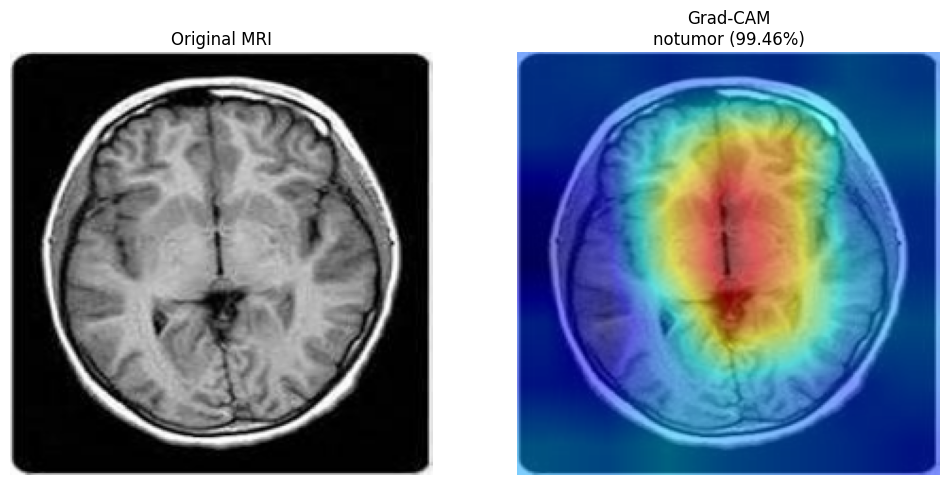

('notumor', 99.45949912071228)

In [ ]:
predict_with_gradcam_efficientnet(
    "data\\Testing\\pituitary\\Te-pi_36.jpg",
    model3,
    device
)

# Single Image Prediction

To demonstrate the practical application of the trained model, a prediction function was implemented to classify an individual brain MRI image. The input image undergoes the same preprocessing steps used during model evaluation, ensuring consistency between training and inference.

For each input image, the model predicts the most probable brain tumor class along with its confidence score. The original MRI image is displayed alongside the predicted class, and a probability distribution across all four classes is presented using a bar chart. This provides a clear visualization of the model's confidence and helps assess the certainty of its predictions for individual cases.

In [ ]:
# Same preprocessing used during testing
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

def predict_image(image_path, model, device):
    """
    Predict the tumor class for a single MRI image.
    """

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Preprocess
    image_tensor = test_transform(image).unsqueeze(0).to(device)

    # Prediction
    model.eval()

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = F.softmax(outputs, dim=1)[0]

    confidence, predicted = torch.max(probabilities, dim=0)

    predicted_class = class_names[predicted.item()]
    confidence = confidence.item() * 100

    # ---------- Display MRI ----------
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Predicted: {predicted_class.upper()}\nConfidence: {confidence:.2f}%",
        fontsize=14,
        fontweight="bold"
    )
    plt.show()

    # ---------- Probability Bar Chart ----------
    probs = (probabilities.cpu().numpy()) * 100

    plt.figure(figsize=(7, 4))
    plt.bar(class_names, probs)
    plt.ylabel("Probability (%)")
    plt.xlabel("Classes")
    plt.title("Prediction Confidence")
    plt.ylim(0, 100)

    for i, p in enumerate(probs):
        plt.text(i, p + 1, f"{p:.1f}%", ha="center", fontsize=10)

    plt.show()

    # ---------- Print Nicely ----------
    print("=" * 35)
    print(f"Predicted Class : {predicted_class.upper()}")
    print(f"Confidence      : {confidence:.2f}%")
    print("=" * 35)

    print("\nClass Probabilities:")
    for cls, prob in zip(class_names, probs):
        print(f"{cls:<12} : {prob:.2f}%")

    return predicted_class, confidence, probs

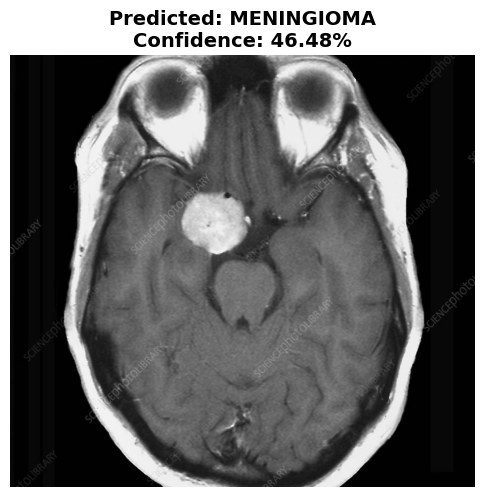

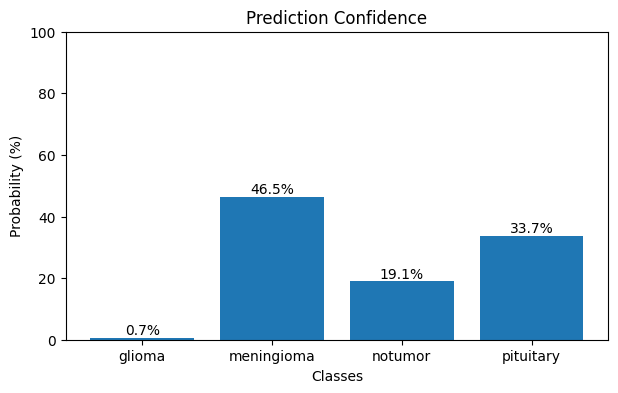

Predicted Class : MENINGIOMA
Confidence      : 46.48%

Class Probabilities:
glioma       : 0.71%
meningioma   : 46.48%
notumor      : 19.06%
pituitary    : 33.74%


('meningioma',
 46.48425877094269,
 array([ 0.7133519, 46.48426  , 19.061708 , 33.740685 ], dtype=float32))

In [210]:
predict_image(
    "external_testdata\\meningioma2.jpg",
    model3,
    device
)

In [211]:
# Same preprocessing used during testing
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

def predict_image_densenet(image_path, model2, device):

    image = Image.open(image_path).convert("RGB")

    image_tensor = test_transform(image).unsqueeze(0).to(device)

    model2.eval()

    with torch.no_grad():
        outputs = model2(image_tensor)
        probabilities = F.softmax(outputs, dim=1)[0]

    confidence, predicted = torch.max(probabilities, dim=0)

    predicted_class = class_names[predicted.item()]
    confidence = confidence.item() * 100

    # Display MRI
    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Predicted: {predicted_class.upper()}\nConfidence: {confidence:.2f}%",
        fontsize=14,
        fontweight="bold"
    )
    plt.show()

    # Probability Bar Chart
    probs = probabilities.cpu().numpy() * 100

    plt.figure(figsize=(7,4))
    plt.bar(class_names, probs)
    plt.ylabel("Probability (%)")
    plt.xlabel("Classes")
    plt.title("Prediction Confidence")
    plt.ylim(0,100)

    for i, p in enumerate(probs):
        plt.text(i, p + 1, f"{p:.1f}%", ha="center", fontsize=10)

    plt.show()

    print("="*35)
    print(f"Predicted Class : {predicted_class.upper()}")
    print(f"Confidence      : {confidence:.2f}%")
    print("="*35)

    print("\nClass Probabilities:")
    for cls, prob in zip(class_names, probs):
        print(f"{cls:<12} : {prob:.2f}%")

    return predicted_class, confidence, probs

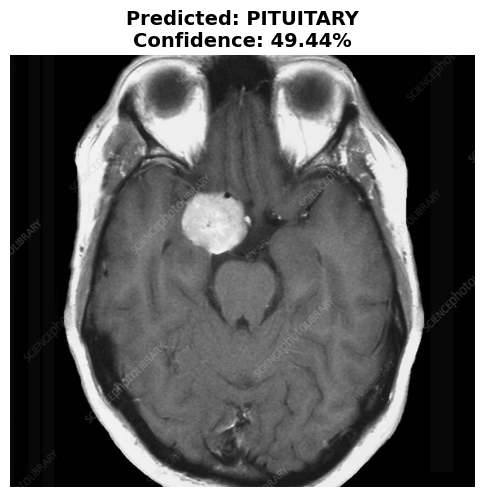

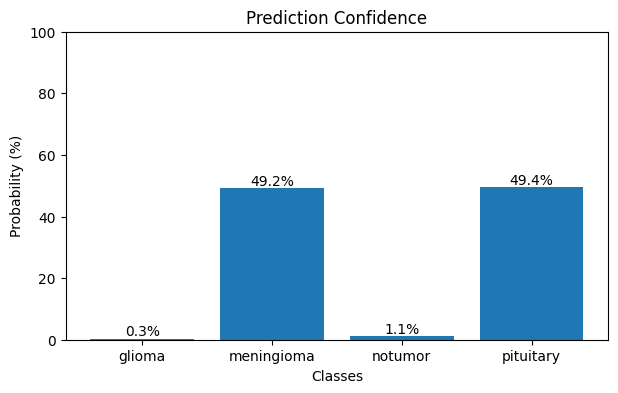

Predicted Class : PITUITARY
Confidence      : 49.44%

Class Probabilities:
glioma       : 0.25%
meningioma   : 49.17%
notumor      : 1.13%
pituitary    : 49.44%


('pituitary',
 49.44460690021515,
 array([ 0.25148505, 49.171673  ,  1.1322321 , 49.444607  ], dtype=float32))

In [212]:
predict_image_densenet(
    "external_testdata\\meningioma2.jpg",
    model2,
    device
)

In [ ]:
# Same preprocessing used during testing
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

def predict_image_efficientnet(image_path, model3, device):

    image = Image.open(image_path).convert("RGB")

    image_tensor = test_transform(image).unsqueeze(0).to(device)

    model3.eval()

    with torch.no_grad():
        outputs = model3(image_tensor)
        probabilities = F.softmax(outputs, dim=1)[0]

    confidence, predicted = torch.max(probabilities, dim=0)

    predicted_class = class_names[predicted.item()]
    confidence = confidence.item() * 100

    # Display MRI
    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Predicted: {predicted_class.upper()}\nConfidence: {confidence:.2f}%",
        fontsize=14,
        fontweight="bold"
    )
    plt.show()

    # Probability Bar Chart
    probs = probabilities.cpu().numpy() * 100

    plt.figure(figsize=(7,4))
    plt.bar(class_names, probs)
    plt.ylabel("Probability (%)")
    plt.xlabel("Classes")
    plt.title("Prediction Confidence")
    plt.ylim(0,100)

    for i, p in enumerate(probs):
        plt.text(i, p + 1, f"{p:.1f}%", ha="center", fontsize=10)

    plt.show()

    print("="*35)
    print(f"Predicted Class : {predicted_class.upper()}")
    print(f"Confidence      : {confidence:.2f}%")
    print("="*35)

    print("\nClass Probabilities:")
    for cls, prob in zip(class_names, probs):
        print(f"{cls:<12} : {prob:.2f}%")

    return predicted_class, confidence, probs

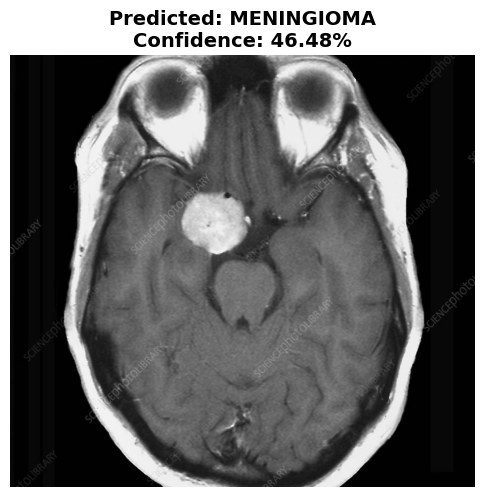

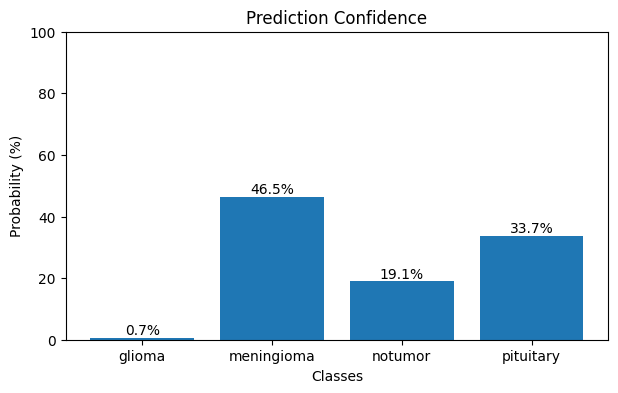

Predicted Class : MENINGIOMA
Confidence      : 46.48%

Class Probabilities:
glioma       : 0.71%
meningioma   : 46.48%
notumor      : 19.06%
pituitary    : 33.74%


('meningioma',
 46.48425877094269,
 array([ 0.7133519, 46.48426  , 19.061708 , 33.740685 ], dtype=float32))

In [213]:
predict_image_efficientnet(
    "external_testdata\\meningioma2.jpg",
    model3,
    device
)

# Model Comparison

The performance of the three pretrained convolutional neural network architectures was compared using their test accuracy on the brain MRI test dataset. This comparison highlights the effectiveness of each transfer learning model and helps identify the architecture that achieved the best classification performance.

In [163]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "ResNet50",
        "DenseNet121",
        "EfficientNet-B0"
    ],
    "Test Accuracy (%)": [
        accuracy,   # ResNet50 accuracy
        accuracy2,  # DenseNet121 accuracy
        accuracy3   # EfficientNet-B0 accuracy
    ]
})

comparison = comparison.sort_values(
    by="Test Accuracy (%)",
    ascending=False
).reset_index(drop=True)

comparison

,Model,Test Accuracy (%)
0,EfficientNet-B0,0.877500
1,ResNet50,0.868125
2,DenseNet121,0.867500


In [167]:
comparison = pd.DataFrame({
    "Model": [
        "ResNet50",
        "DenseNet121",
        "EfficientNet-B0"
    ],
    "Accuracy (%)": [87, 87, 88],
    "Precision": [0.88, 0.87, 0.88],
    "Recall": [0.87, 0.87, 0.88],
    "F1-Score": [0.87, 0.86, 0.87]
})

comparison

,Model,Accuracy (%),Precision,Recall,F1-Score
0,ResNet50,87,0.88,0.87,0.87
1,DenseNet121,87,0.87,0.87,0.86
2,EfficientNet-B0,88,0.88,0.88,0.87
